In [58]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator
sim = AerSimulator()

# Gate Review

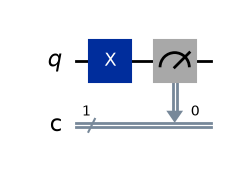

{'1': 1000}


In [60]:
# X Gate - Bit Flip
qc = QuantumCircuit(1, 1)
qc.x(0)
qc.measure(0, 0)
display(qc.draw('mpl'))

job = sim.run(qc, shots=1000)
counts = job.result().get_counts()
print(counts) # |0> to |1>

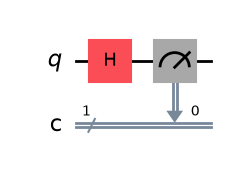

{'1': 493, '0': 507}


In [61]:
# H Gate - Hadamard
qc = QuantumCircuit(1, 1)
qc.h(0)
qc.measure(0, 0)
display(qc.draw('mpl'))

job = sim.run(qc, shots=1000)
counts = job.result().get_counts()
print(counts) #|0> to |+>

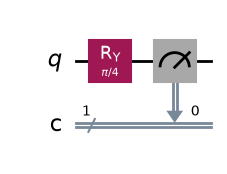

pi/4: {'1': 148, '0': 852}


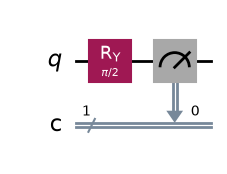

pi/2: {'1': 515, '0': 485}


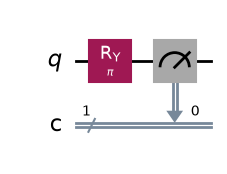

pi: {'1': 1000}


In [62]:
# Ry gate - rotate around y-axis by angle theta
angles = [np.pi/4, np.pi/2, np.pi]
labels = ["pi/4", "pi/2", "pi"]
for angle, label in zip(angles, labels):
    qc = QuantumCircuit(1, 1)
    qc.ry(angle, 0)
    qc.measure(0, 0)
    display(qc.draw('mpl'))

    job = sim.run(qc, shots=1000)
    counts = job.result().get_counts()
    print(f"{label}: {counts}")

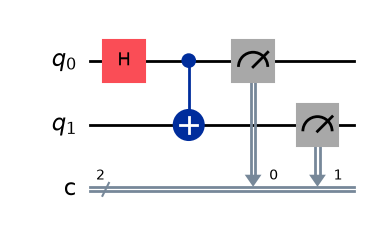

{'00': 506, '11': 494}


In [63]:
# CNOT gate - flip qubit 1 if qubit 0 is |1>
qc = QuantumCircuit(2, 2)
qc.h(0) # put qubit 0 (control) in superposition to entangle qubits
qc.cx(0, 1)
qc.measure([0, 1], [0, 1])
display(qc.draw('mpl'))

job = sim.run(qc, shots=1000)
counts = job.result().get_counts()
print(counts)

# Iris dataset

## Exploration

In [64]:
iris = load_iris()
X = iris.data
y = iris.target
print("Feature names:", iris.feature_names)
print("Class names:  ", iris.target_names)
print("X shape:      ", X.shape)
print("y shape:      ", y.shape)
print("Class counts: ", np.bincount(y))
print("Feature ranges:")
for i, name in enumerate(iris.feature_names):
    print(f"    {name}: [{X[:, i].min():.2f}, {X[:, i].max():.2f}]")

Feature names: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Class names:   ['setosa' 'versicolor' 'virginica']
X shape:       (150, 4)
y shape:       (150,)
Class counts:  [50 50 50]
Feature ranges:
    sepal length (cm): [4.30, 7.90]
    sepal width (cm): [2.00, 4.40]
    petal length (cm): [1.00, 6.90]
    petal width (cm): [0.10, 2.50]


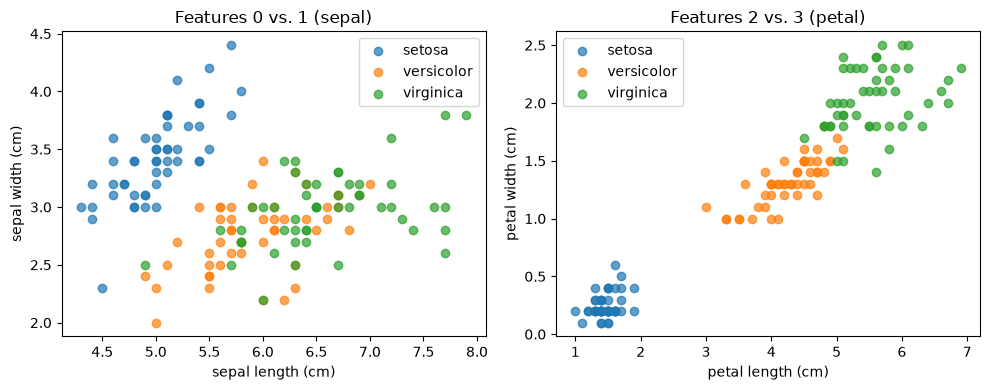

In [65]:
# plot data
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

for c, name in enumerate(iris.target_names):
    mask = y == c
    axes[0].scatter(X[mask, 0], X[mask, 1], label=name, alpha=0.7)
    axes[1].scatter(X[mask, 2], X[mask, 3], label=name, alpha=0.7)

axes[0].set_xlabel(iris.feature_names[0])
axes[0].set_ylabel(iris.feature_names[1])
axes[0].set_title("Features 0 vs. 1 (sepal)")
axes[0].legend()

axes[1].set_xlabel(iris.feature_names[2])
axes[1].set_ylabel(iris.feature_names[3])
axes[1].set_title("Features 2 vs. 3 (petal)")
axes[1].legend()

plt.tight_layout()
plt.savefig("../results/iris_scatter.png")
plt.show()

### Notes
Setosa immediately distinguishable through both sepal and petal features. Versicolor and Virginica not easily separable by sepal length/width but separable by petal length/width.

## Preprocessing

In [66]:
# 2 classes: setosa vs versicolor
X_2class = iris.data[:100]
y_2class = iris.target[:100]

# normalize features to [0, pi] for angle encoding
# become valid rotation angles for Ry gate
scaler = MinMaxScaler(feature_range=(0, np.pi))
X_scaled = scaler.fit_transform(X_2class)

print("Before normalization:")
print(f"  Min: {X_2class.min():.4f}")
print(f"  Max: {X_2class.max():.4f}")
print("After normalization:")
print(f"  Min: {X_scaled.min():.4f}")
print(f"  Max: {X_scaled.max():.4f}")

Before normalization:
  Min: 0.1000
  Max: 7.0000
After normalization:
  Min: 0.0000
  Max: 3.1416


In [67]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_2class, test_size=0.2, random_state=42
)
print("Train size:", len(X_train))
print("Test size:", len(X_test))
print(f"Train class counts: {np.bincount(y_train)}")
print(f"Test class counts:  {np.bincount(y_test)}")

Train size: 80
Test size: 20
Train class counts: [38 42]
Test class counts:  [12  8]


# Angle Encoding

In [73]:
'''
Angle encode normalized feature vector onto qubits using Ry rotation.
Returns: unmeasured quantum circuit
'''
def encode_data(x):
    qc = QuantumCircuit(len(x))
    for i, x_i in enumerate(x):
        qc.ry(x_i, i)
    return qc

Sample 1 | versicolor | features=[1.62897397 1.04719755 2.68184739 2.21759481]


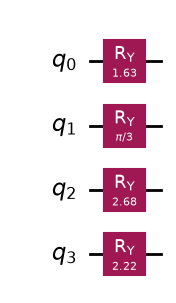

Sample 2 | versicolor | features=[1.51261869 1.30899694 2.37535054 2.21759481]


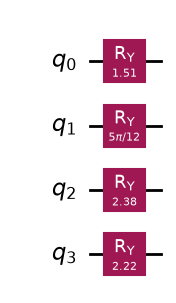

Sample 3 | setosa | features=[0.81448698 1.83259571 0.45974527 0.5543987 ]


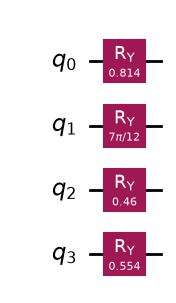

Sample 4 | setosa | features=[0.11635528 1.57079633 0.22987263 0.18479957]


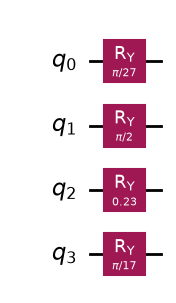

Sample 5 | versicolor | features=[1.51261869 0.65449847 2.22210212 1.84799568]


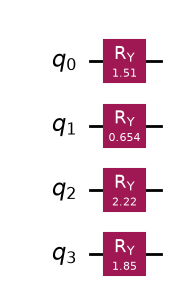

In [92]:
for i in range(5):
    qc = encode_data(X_train[i])
    print(f"Sample {i+1} | {iris.target_names[y_train[i]]} | features={X_train[i]}")
    display(qc.draw('mpl'))

## Tests

In [91]:
for i in range(5):
    qc = encode_data(X_train[i])
    qc.measure_all()
    job = sim.run(qc, shots=500)
    counts = job.result().get_counts()
    label = iris.target_names[y_train[i]]
    print(f"Sample {i+1} | {label:10s} | {dict(sorted(counts.items()))}")

Sample 1 | versicolor | {'0000': 1, '0001': 1, '0010': 2, '0100': 30, '0101': 50, '0110': 10, '0111': 8, '1000': 9, '1001': 6, '1010': 3, '1011': 2, '1100': 130, '1101': 152, '1110': 50, '1111': 46}
Sample 2 | versicolor | {'0000': 1, '0001': 5, '0010': 1, '0011': 2, '0100': 30, '0101': 19, '0110': 23, '0111': 18, '1000': 17, '1001': 13, '1010': 5, '1011': 13, '1100': 122, '1101': 93, '1110': 76, '1111': 62}
Sample 3 | setosa     | {'0000': 134, '0001': 27, '0010': 235, '0011': 37, '0100': 8, '0101': 1, '0110': 14, '0111': 2, '1000': 12, '1001': 3, '1010': 21, '1011': 5, '1101': 1}
Sample 4 | setosa     | {'0000': 247, '0010': 243, '0100': 1, '0110': 2, '1000': 3, '1010': 4}
Sample 5 | versicolor | {'0000': 15, '0001': 20, '0100': 70, '0101': 55, '0110': 5, '0111': 8, '1000': 39, '1001': 32, '1010': 3, '1100': 116, '1101': 110, '1110': 15, '1111': 12}


In [95]:
# same sample run multiple times has similar but not identical results due to quantum randomness
qc = encode_data(X_train[0])
qc.measure_all()

run1 = sim.run(qc, shots=500).result().get_counts()
run2 = sim.run(qc, shots=500).result().get_counts()

print(dict(sorted(run1.items())))
print(dict(sorted(run2.items())))

{'0000': 1, '0001': 4, '0010': 1, '0100': 29, '0101': 35, '0110': 18, '0111': 10, '1000': 11, '1001': 7, '1010': 4, '1011': 3, '1100': 131, '1101': 150, '1110': 40, '1111': 56}
{'0000': 2, '0001': 4, '0010': 1, '0011': 1, '0100': 35, '0101': 31, '0110': 10, '0111': 11, '1000': 9, '1001': 7, '1010': 1, '1011': 5, '1100': 155, '1101': 141, '1110': 53, '1111': 34}


### Notes
Versicolor samples seem to have the largest 1100 and 1101 populations while setosa ones tend to cluster at 0000 and 0010.